# PCA, Real Data, and Eigenfaces

We start with a Gaussian cloud to see PCA geometrically.
Then we move to ovarian cancer data.
Then we build eigenfaces and use them to reconstruct faces, a dog image, and a cup image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import scipy.io
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["image.cmap"] = "gray"

In [2]:
def pca_svd(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, VT = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ VT.T
    var = (S**2) / (X.shape[0] - 1)
    exp_var = var / var.sum()
    cum_var = np.cumsum(exp_var)
    return Xc, U, S, VT, scores, exp_var, cum_var

def draw_pc_axes(ax, mean, VT, S, n_samples, scale=3.0):
    stds = S / np.sqrt(n_samples - 1)
    colors = ["crimson", "royalblue", "darkgreen"]
    for k in range(min(VT.shape[0], 3)):
        v = VT[k]
        length = scale * stds[k]
        p1 = mean - length * v
        p2 = mean + length * v
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=colors[k], linewidth=3)

def face_image(vec, m, n):
    return np.reshape(vec, (m, n)).T

def make_gallery(matrix, m, n, nrows, ncols):
    canvas = np.zeros((n * nrows, m * ncols))
    count = 0
    for j in range(nrows):
        for k in range(ncols):
            if count < matrix.shape[1]:
                canvas[j*n:(j+1)*n, k*m:(k+1)*m] = face_image(matrix[:, count], m, n)
                count += 1
    return canvas

def reconstruct_in_basis(vec, mean, basis, r):
    return mean + basis[:, :r] @ (basis[:, :r].T @ (vec - mean))

def image_to_face_vector(path, m, n):
    arr = np.array(Image.open(path).convert("L").resize((m, n)), dtype=float)
    return arr.T.reshape(-1)

def first_existing(candidates):
    for c in candidates:
        if Path(c).exists():
            return c
    raise FileNotFoundError(f"None of these files were found: {candidates}")

## Part 1: PCA on a Gaussian cloud

The point here is geometry:
center the cloud, find the principal directions, and look at the data in PC coordinates.

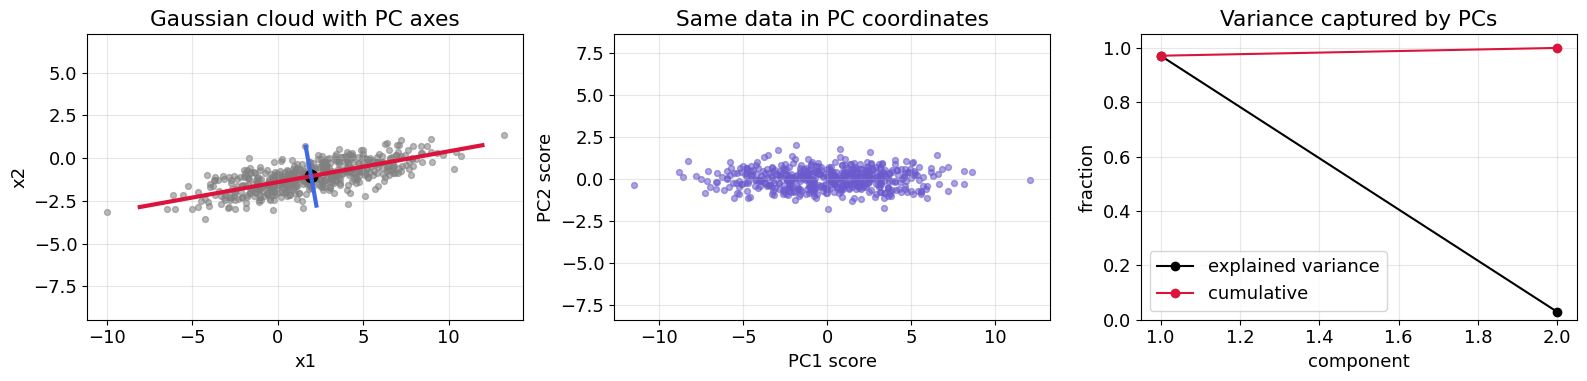

Principal directions (rows of VT):
[[-0.9841 -0.1775]
 [ 0.1775 -0.9841]]

Explained variance fractions:
[0.9713 0.0287]


In [3]:
np.random.seed(7)

Z = np.random.randn(500, 2)
A = np.array([[3.2, 1.4],
              [0.3, 0.8]])
Xg = Z @ A.T + np.array([2.0, -1.0])

Xgc, Ug, Sg, VTg, scores_g, exp_g, cum_g = pca_svd(Xg)
mean_g = Xg.mean(axis=0)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].scatter(Xg[:, 0], Xg[:, 1], s=18, alpha=0.55, color="gray")
ax[0].scatter(mean_g[0], mean_g[1], color="black", s=80)
draw_pc_axes(ax[0], mean_g, VTg, Sg, Xg.shape[0])
ax[0].set_title("Gaussian cloud with PC axes")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")
ax[0].axis("equal")
ax[0].grid(alpha=0.3)

ax[1].scatter(scores_g[:, 0], scores_g[:, 1], s=18, alpha=0.55, color="slateblue")
ax[1].set_title("Same data in PC coordinates")
ax[1].set_xlabel("PC1 score")
ax[1].set_ylabel("PC2 score")
ax[1].axis("equal")
ax[1].grid(alpha=0.3)

ax[2].plot(np.arange(1, len(exp_g)+1), exp_g, "-o", color="black", label="explained variance")
ax[2].plot(np.arange(1, len(cum_g)+1), cum_g, "-o", color="crimson", label="cumulative")
ax[2].set_title("Variance captured by PCs")
ax[2].set_xlabel("component")
ax[2].set_ylabel("fraction")
ax[2].set_ylim(0, 1.05)
ax[2].grid(alpha=0.3)
ax[2].legend()

plt.tight_layout()
plt.show()

print("Principal directions (rows of VT):")
print(np.round(VTg, 4))
print()
print("Explained variance fractions:")
print(np.round(exp_g, 4))

The first PC points along the longest direction of the cloud.
After rotation into PC coordinates, the data look aligned with the axes.

## Part 2: PCA on ovarian cancer data

Now we do the same PCA workflow on a real dataset.
We center the variables, compute an SVD, inspect variance capture, and plot samples in low-dimensional PC space.

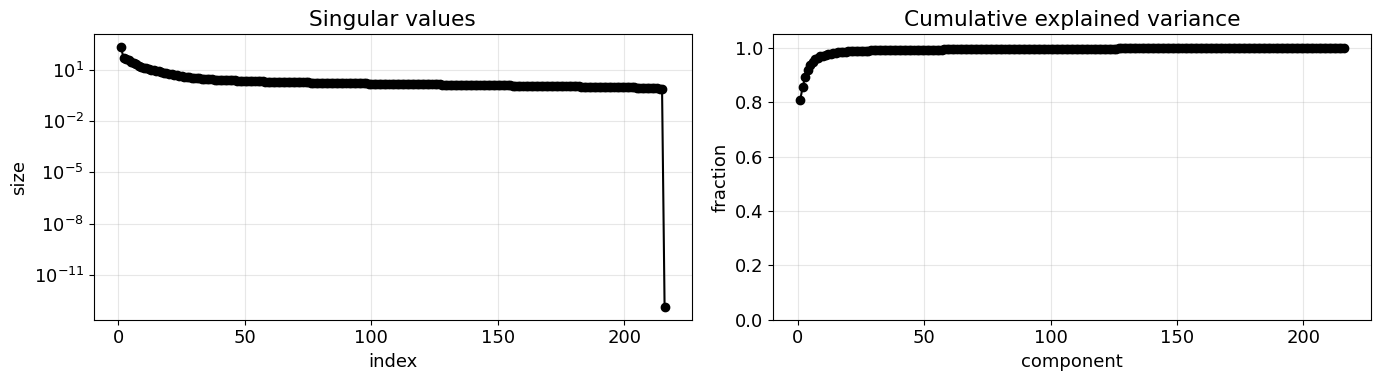

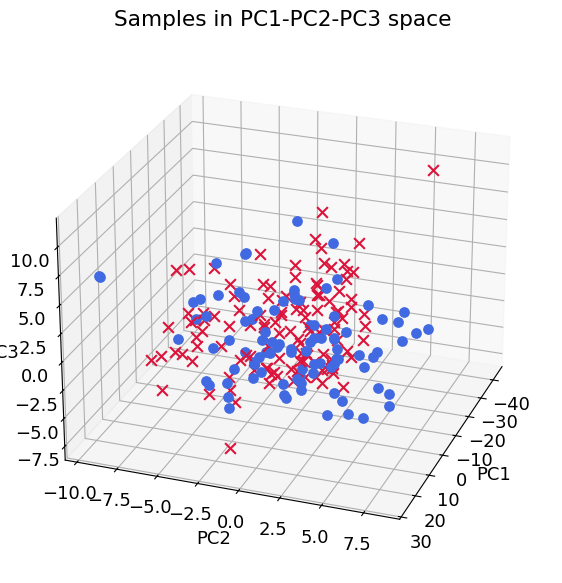

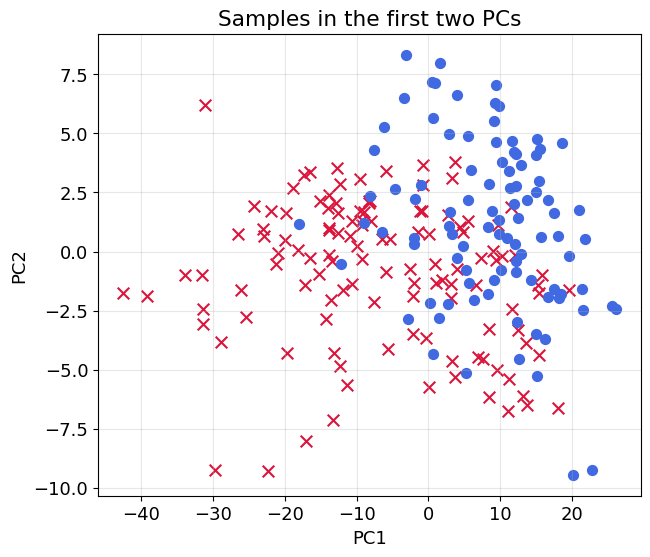

obs shape: (216, 4000)
first 6 explained-variance fractions: [0.8094 0.048  0.037  0.0257 0.0168 0.0124]
variance captured by first 3 PCs: 0.8944


In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

obs = np.loadtxt("ovariancancer_obs.csv", delimiter=",")

with open("ovariancancer_grp.csv", "r") as f:
    grp = [line.strip() for line in f if line.strip()]

Xco, Uo, So, VTo, scores_o, exp_o, cum_o = pca_svd(obs)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].semilogy(np.arange(1, len(So)+1), So, "-o", color="black")
ax[0].set_title("Singular values")
ax[0].set_xlabel("index")
ax[0].set_ylabel("size")
ax[0].grid(alpha=0.3)

ax[1].plot(np.arange(1, len(cum_o)+1), cum_o, "-o", color="black")
ax[1].set_title("Cumulative explained variance")
ax[1].set_xlabel("component")
ax[1].set_ylabel("fraction")
ax[1].set_ylim(0, 1.05)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for j in range(obs.shape[0]):
    x, y, z = scores_o[j, 0], scores_o[j, 1], scores_o[j, 2]
    if grp[j] == "Cancer":
        ax.scatter(x, y, z, marker="x", color="crimson", s=60)
    else:
        ax.scatter(x, y, z, marker="o", color="royalblue", s=45)

ax.set_title("Samples in PC1-PC2-PC3 space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.view_init(25, 20)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for j in range(obs.shape[0]):
    if grp[j] == "Cancer":
        ax.scatter(scores_o[j, 0], scores_o[j, 1], marker="x", color="crimson", s=70)
    else:
        ax.scatter(scores_o[j, 0], scores_o[j, 1], marker="o", color="royalblue", s=50)

ax.set_title("Samples in the first two PCs")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
plt.show()

print("obs shape:", obs.shape)
print("first 6 explained-variance fractions:", np.round(exp_o[:6], 4))
print("variance captured by first 3 PCs:", np.round(cum_o[2], 4))

## Part 3: Eigenfaces

Here the columns are images, so PCA gives basis images.
The mean face is the center of the dataset, and the leading columns of U are the eigenfaces.

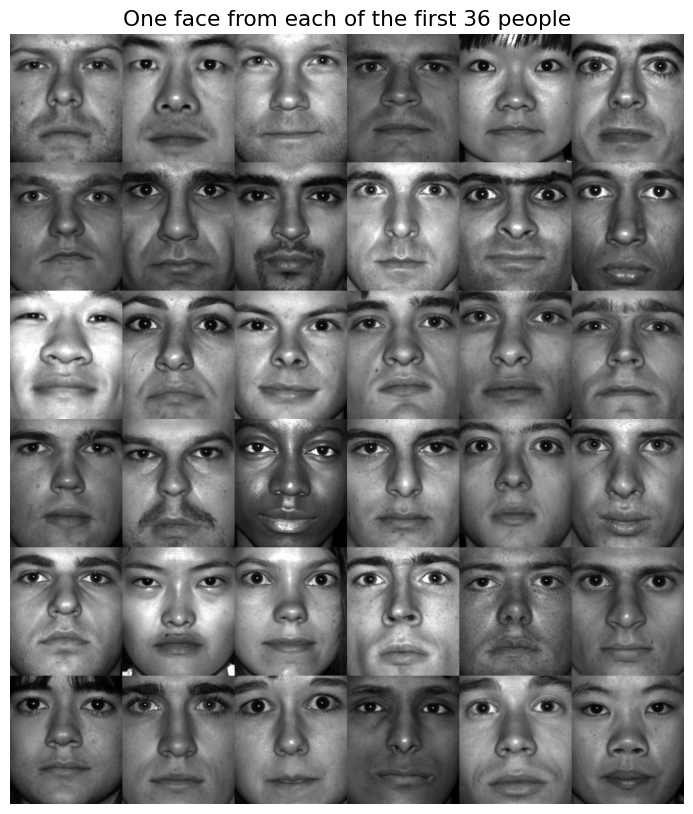

faces matrix shape: (32256, 2410)
image size: (192, 168)
number of people: 38


In [5]:
mat = scipy.io.loadmat("allFaces.mat")
faces = mat["faces"]
m = int(mat["m"][0, 0])
n = int(mat["n"][0, 0])
nfaces = mat["nfaces"].ravel()

starts = np.cumsum(np.r_[0, nfaces[:-1]])
sample_cols = starts[:36]
sample_faces = faces[:, sample_cols]

gallery = make_gallery(sample_faces, m, n, 6, 6)

plt.figure(figsize=(10, 10))
plt.imshow(gallery, cmap="gray")
plt.axis("off")
plt.title("One face from each of the first 36 people")
plt.show()

print("faces matrix shape:", faces.shape)
print("image size:", (n, m))
print("number of people:", len(nfaces))

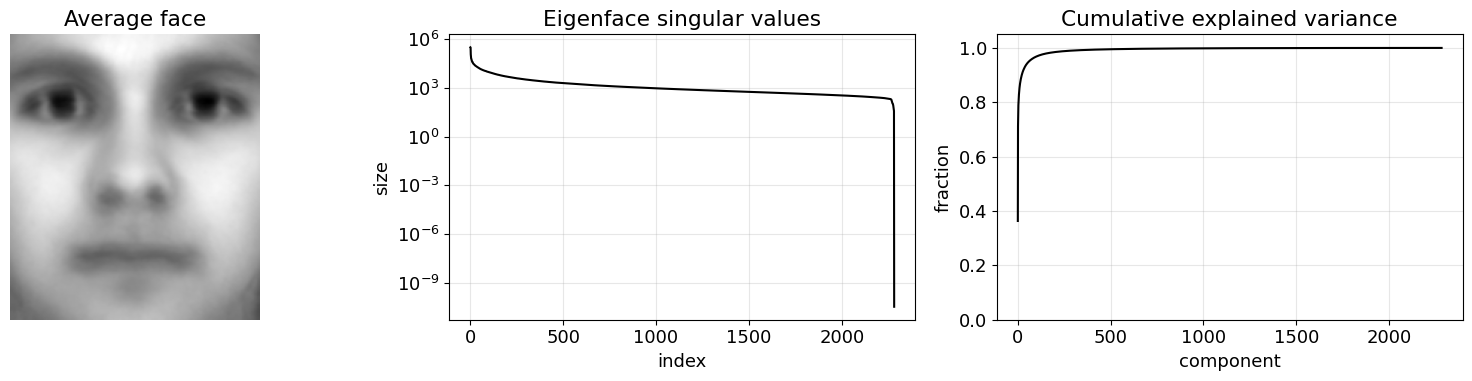

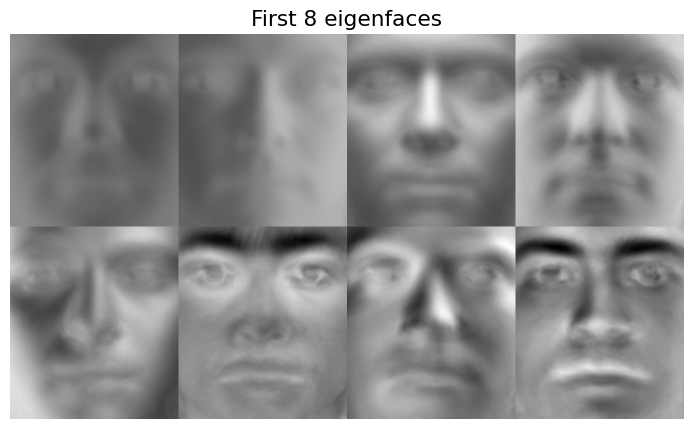

In [6]:
training_faces = faces[:, :np.sum(nfaces[:36])]
avg_face = np.mean(training_faces, axis=1)
Xf = training_faces - avg_face[:, None]

Uf, Sf, VTf = np.linalg.svd(Xf, full_matrices=False)
var_f = (Sf**2) / (Xf.shape[1] - 1)
exp_f = var_f / var_f.sum()
cum_f = np.cumsum(exp_f)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].imshow(face_image(avg_face, m, n), cmap="gray")
ax[0].set_title("Average face")
ax[0].axis("off")

ax[1].semilogy(np.arange(1, len(Sf)+1), Sf, color="black")
ax[1].set_title("Eigenface singular values")
ax[1].set_xlabel("index")
ax[1].set_ylabel("size")
ax[1].grid(alpha=0.3)

ax[2].plot(np.arange(1, len(cum_f)+1), cum_f, color="black")
ax[2].set_title("Cumulative explained variance")
ax[2].set_xlabel("component")
ax[2].set_ylabel("fraction")
ax[2].set_ylim(0, 1.05)
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

eigenface_gallery = make_gallery(Uf[:, :8], m, n, 2, 4)

plt.figure(figsize=(10, 5))
plt.imshow(eigenface_gallery, cmap="gray")
plt.axis("off")
plt.title("First 8 eigenfaces")
plt.show()

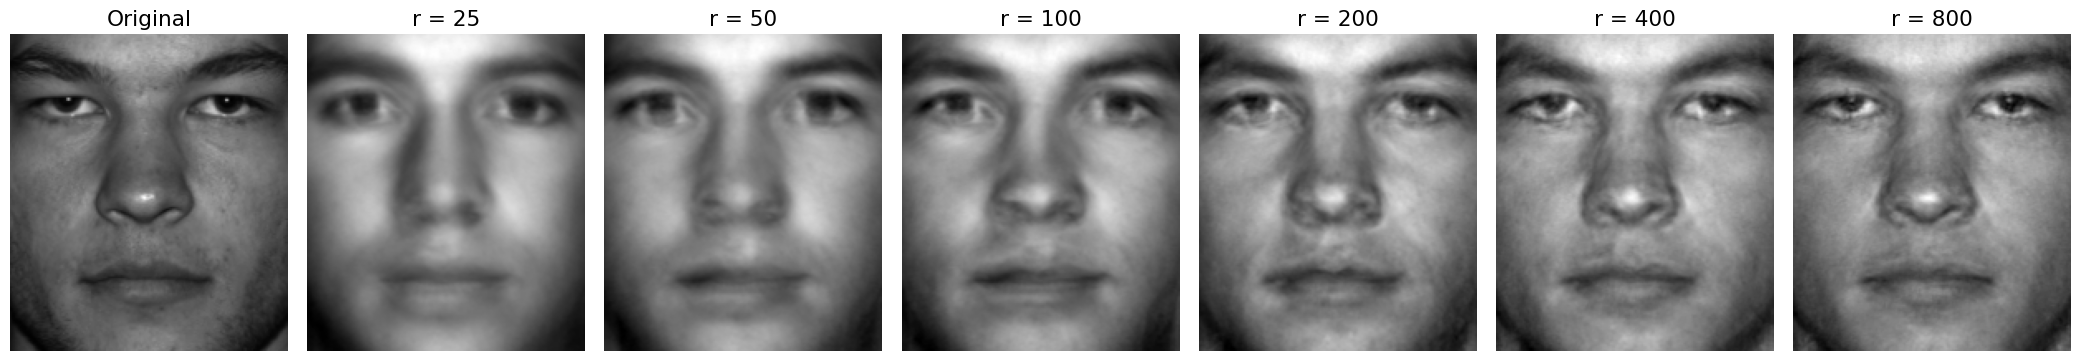

In [7]:
test_idx = int(np.sum(nfaces[:36]))
test_face = faces[:, test_idx]
test_face_ms = test_face - avg_face

r_list = [25, 50, 100, 200, 400, 800]
r_list = [r for r in r_list if r <= Uf.shape[1]]

fig, axes = plt.subplots(1, len(r_list) + 1, figsize=(3 * (len(r_list) + 1), 4))

axes[0].imshow(face_image(test_face, m, n), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for j, r in enumerate(r_list, start=1):
    recon = avg_face + Uf[:, :r] @ (Uf[:, :r].T @ test_face_ms)
    axes[j].imshow(face_image(recon, m, n), cmap="gray")
    axes[j].set_title(f"r = {r}")
    axes[j].axis("off")

plt.tight_layout()
plt.show()

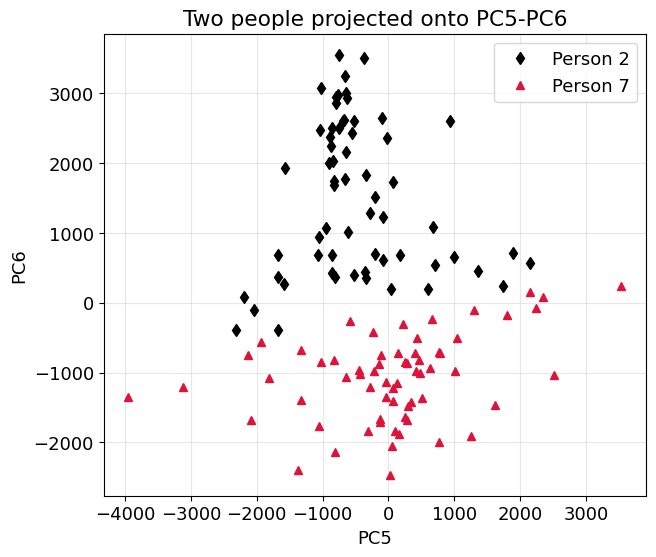

In [8]:
P1num = 2
P2num = 7

a1, b1 = np.sum(nfaces[:P1num-1]), np.sum(nfaces[:P1num])
a2, b2 = np.sum(nfaces[:P2num-1]), np.sum(nfaces[:P2num])

P1 = faces[:, a1:b1] - avg_face[:, None]
P2 = faces[:, a2:b2] - avg_face[:, None]

modes = [4, 5]
coords1 = Uf[:, modes].T @ P1
coords2 = Uf[:, modes].T @ P2

plt.figure(figsize=(7, 6))
plt.plot(coords1[0, :], coords1[1, :], "d", color="black", label="Person 2")
plt.plot(coords2[0, :], coords2[1, :], "^", color="crimson", label="Person 7")
plt.xlabel("PC5")
plt.ylabel("PC6")
plt.title("Two people projected onto PC5-PC6")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Part 4: Reconstructing non-face images with eigenfaces

Now we force other images into the face subspace.
This is not supposed to give a faithful semantic reconstruction.
It shows what the eigenface basis can represent and what it cannot.

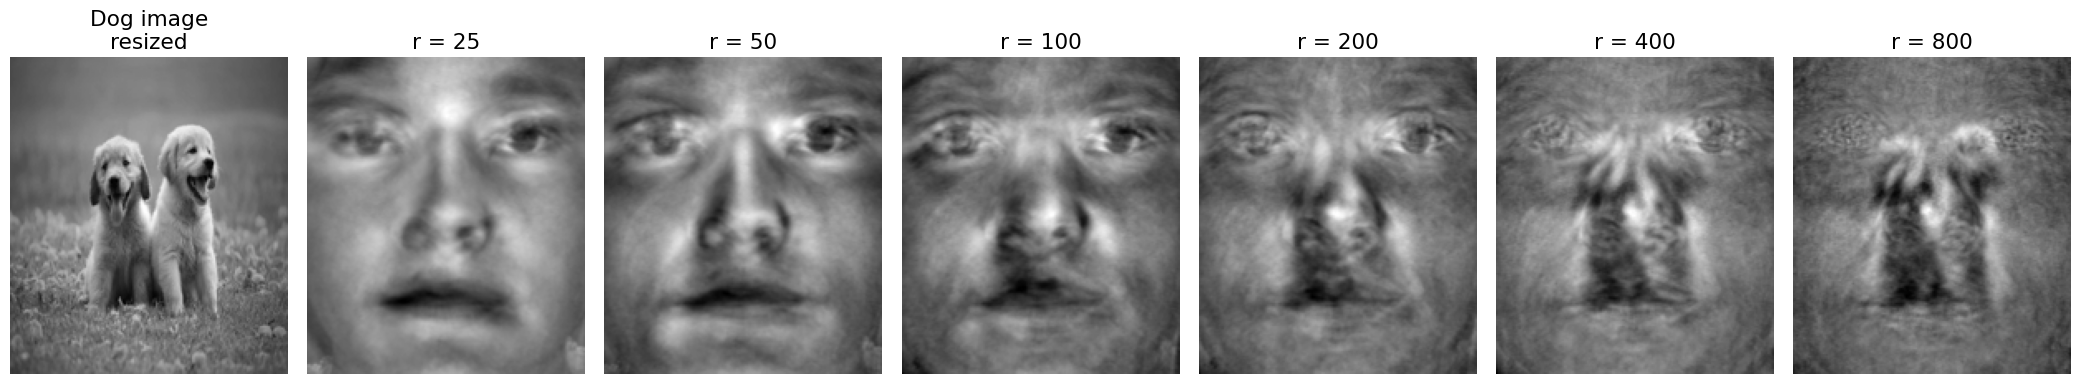

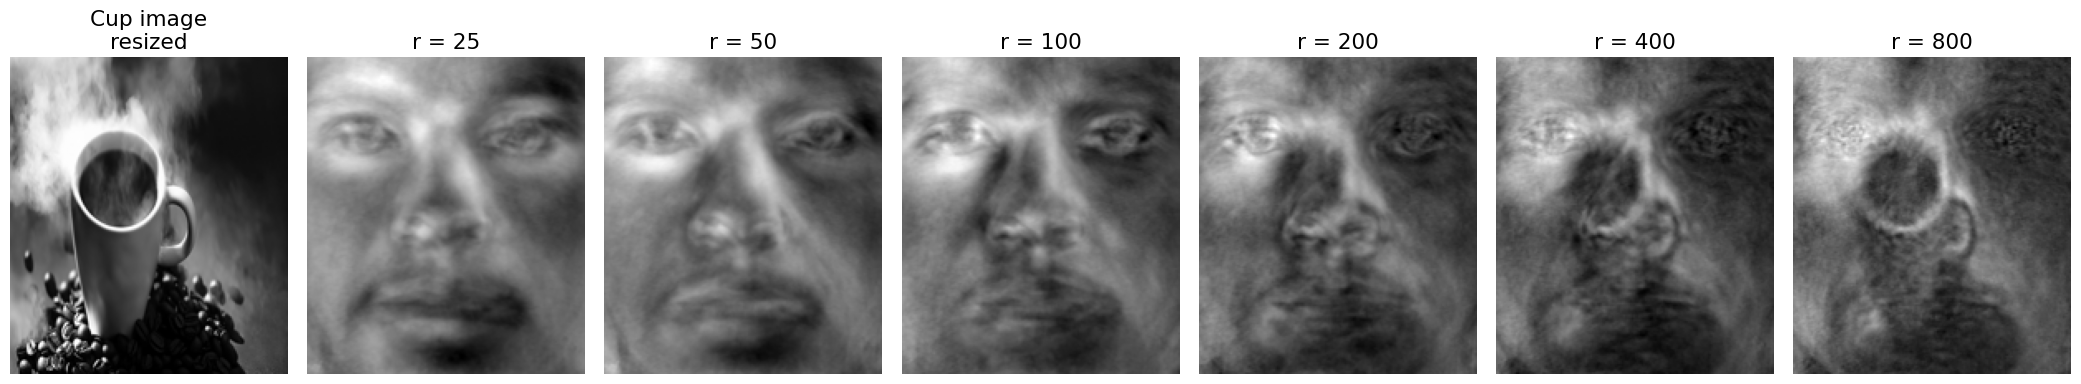

In [9]:
dog_path = first_existing(["dogs.jpg", "dogs.png"])
cup_path = first_existing(["cup.jpg", "cup.png"])

r_list_img = [25, 50, 100, 200, 400, 800]
r_list_img = [r for r in r_list_img if r <= Uf.shape[1]]

def show_external_reconstruction(path, title):
    vec = image_to_face_vector(path, m, n)
    fig, axes = plt.subplots(1, len(r_list_img) + 1, figsize=(3 * (len(r_list_img) + 1), 4))

    axes[0].imshow(face_image(vec, m, n), cmap="gray")
    axes[0].set_title(f"{title}\nresized")
    axes[0].axis("off")

    for j, r in enumerate(r_list_img, start=1):
        recon = reconstruct_in_basis(vec, avg_face, Uf, r)
        axes[j].imshow(face_image(recon, m, n), cmap="gray")
        axes[j].set_title(f"r = {r}")
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

show_external_reconstruction(dog_path, "Dog image")
show_external_reconstruction(cup_path, "Cup image")

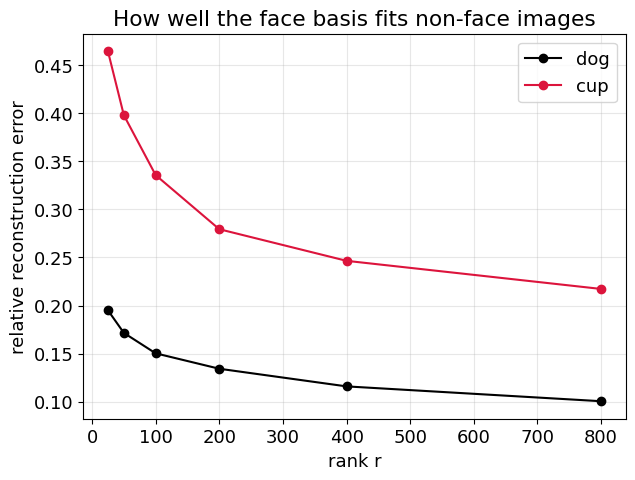

In [10]:
dog_vec = image_to_face_vector(dog_path, m, n)
cup_vec = image_to_face_vector(cup_path, m, n)

dog_err = []
cup_err = []

for r in r_list_img:
    dog_recon = reconstruct_in_basis(dog_vec, avg_face, Uf, r)
    cup_recon = reconstruct_in_basis(cup_vec, avg_face, Uf, r)
    dog_err.append(np.linalg.norm(dog_vec - dog_recon) / np.linalg.norm(dog_vec))
    cup_err.append(np.linalg.norm(cup_vec - cup_recon) / np.linalg.norm(cup_vec))

plt.figure(figsize=(7, 5))
plt.plot(r_list_img, dog_err, "-o", color="black", label="dog")
plt.plot(r_list_img, cup_err, "-o", color="crimson", label="cup")
plt.xlabel("rank r")
plt.ylabel("relative reconstruction error")
plt.title("How well the face basis fits non-face images")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Short takeaways

- PCA rotates data into orthogonal directions of decreasing variance.
- For point clouds, the PCs are geometric axes.
- For gene-expression data, the PCs give low-dimensional coordinates for samples.
- For face images, the PCs become eigenfaces.
- When we project a dog or a cup into the face basis, we only keep the part that looks face-like to that basis.